In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

ELOS = list(range(800, 2200, 100))
FEATURES = ['delta', 'fragility_score', 'variance']

In [19]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.tail()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_800,...,historical_best_1900,is_historical_best_1900,group_count_2000,winrate_2000,historical_best_2000,is_historical_best_2000,group_count_2100,winrate_2100,historical_best_2100,is_historical_best_2100
265,rnbqkb1r/pp2pp1p/5np1/3p2B1/3P4/2N2N2/PPP2PPP/...,f8g7,104,1678.096154,0.451923,b8c6,0.116353,0.048808,-0.428462,4.0,...,[f8g7],True,51,0.450980,[f8g7],True,39,0.487179,[f8g7],True
266,rnbqkb1r/pp3ppp/4pn2/1B1p4/3P4/2N2N2/PPP2PPP/R...,c8d7,110,1599.345455,0.518182,c8d7,0.366785,0.667710,-0.324725,8.0,...,[c8d7],True,37,0.513514,[c8d7],True,31,0.451613,[c8d7],True
267,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,210,1564.290476,0.485714,b8c6,0.295233,0.063857,-0.464949,11.0,...,[f8e7],True,64,0.484375,[f8e7],True,35,0.571429,[f8e7],True
268,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,102,1590.254902,0.480392,b8c6,0.259457,0.063857,-0.446934,4.0,...,[f8e7],True,34,0.441176,[f8e7],True,24,0.375000,[f8e7],True
269,rnbqkbnr/pp3ppp/4p3/3pP3/3P4/5N2/PP3PPP/RNBQKB...,b8c6,103,1590.407767,0.466019,b8c6,0.116353,-0.760091,-0.446039,9.0,...,[b8c6],True,43,0.488372,[b8c6],True,25,0.440000,[b8c6],True


In [20]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100
delta,0.0,0.429558,0.264018,0.381168,0.383096,0.307318,0.344835,0.383697,0.287227,0.381419,0.295741,0.333580,0.323993,0.319882
fragility_score,0.0,0.203624,0.405398,0.303247,0.259231,0.310362,0.335539,0.342494,0.324489,0.316510,0.327698,0.359235,0.330828,0.336821
variance,0.0,0.366818,0.330584,0.315585,0.357673,0.382320,0.319626,0.273809,0.388284,0.302071,0.376561,0.307185,0.345179,0.343296


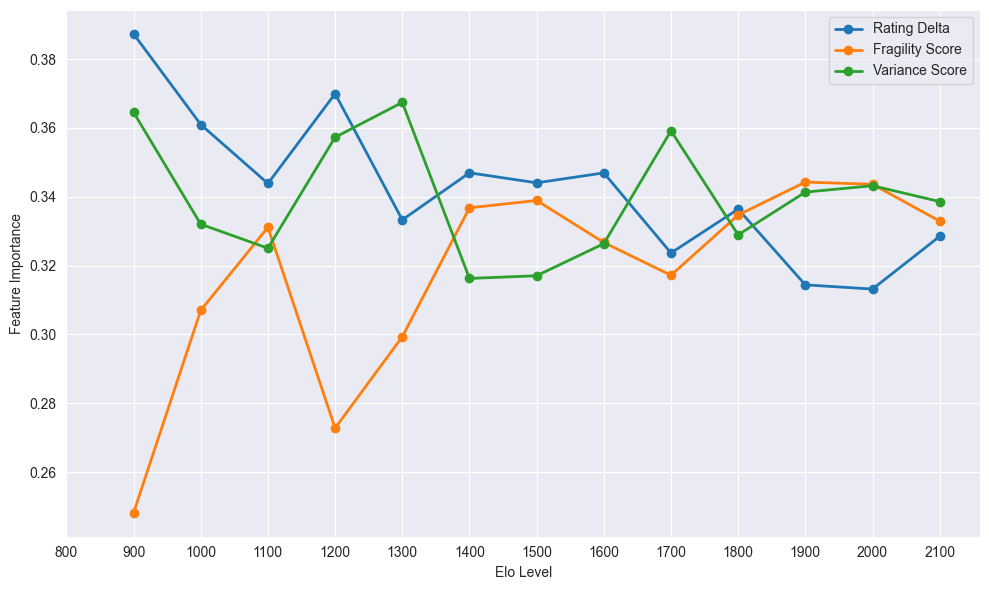

In [31]:
# "Savitzky–Golay Glättung der Feature-Importances") --> smoothed out
plt.figure(figsize=(10, 6))
custom_labels = {
    "fragility_score": "Fragility Score",
    "delta": "Rating Delta",
    "variance": "Variance Score"
}
elos_filtered = [elo for elo in ELOS if elo > 800]
idxs = [i for i, elo in enumerate(ELOS) if elo > 800]

for idx, feature in enumerate(FEATURES):
    y_all = importances.loc[feature, importances.columns].values
    y = y_all[idxs]
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(elos_filtered, y_smooth, marker='o',linewidth=2,label=custom_labels.get(feature, feature))

plt.xlabel("Elo Level")
plt.ylabel("Feature Importance")
plt.xticks(ELOS)
plt.legend()
plt.tight_layout()
plt.savefig("../images/feature_importance.svg")
plt.show()

## Add score and recommend a move

In [22]:
for elo in ELOS:
    score_col = f"score_{elo}"
    rec_col = f"recommended_move_{elo}"
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    elo_col = f"elo_{elo}"
    group_count_col = f"group_count_{elo}"
    hist_col = f"historical_best_{elo}"

    # Assign score
    df[score_col] = (
            importances.loc["delta", elo_col] * df["delta"] +
            importances.loc["fragility_score", elo_col] * df["fragility_score"] +
            importances.loc["variance", elo_col] * df["variance"]
    )

    # Determine the recommended move per FEN based on the score
    idx_best_score = df.groupby("fen")[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best_score, ["fen", "next_move"]].set_index("fen")["next_move"]
    df[rec_col] = df["fen"].map(recommended)

    # Compare recommendations and engine move with historical best
    df[is_best_col] = df.apply(lambda r: r[rec_col] in r[hist_col], axis=1).astype('boolean')
    df[is_engine_col] = df.apply(lambda r: r["engine_move"] in r[hist_col], axis=1).astype('boolean')

    # Mask out positions with too few samples or missing data
    invalid_mask = (
            (df[group_count_col] < 20) |
            (df[group_count_col].isna())
    )
    df.loc[invalid_mask, [is_best_col, is_engine_col]] = pd.NA

    # Exclude rows where engine move is not among the observed moves for that position
    valid_moves_per_fen = df.groupby("fen")["next_move"].agg(set).to_dict()
    df["engine_valid_move"] = df.apply(
        lambda row: row["engine_move"] in valid_moves_per_fen.get(row["fen"], set()),
        axis=1
    )
    df.loc[~df["engine_valid_move"], [is_engine_col]] = pd.NA
    df.drop(columns="engine_valid_move", inplace=True)

In [23]:
df.head()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_800,...,is_best_1900,is_engine_best_1900,score_2000,recommended_move_2000,is_best_2000,is_engine_best_2000,score_2100,recommended_move_2100,is_best_2100,is_engine_best_2100
0,r1b1kbnr/pp2pppp/2n5/3q4/8/2N2N2/PP1P1PPP/R1BQ...,d5d8,150,1899.540000,0.406667,d5d8,0.581441,0.295171,-0.401739,2.0,...,True,True,0.147362,d5d8,True,True,0.147497,d5d8,True,True
1,r1bqkb1r/1p2pppp/p1B2n2/3p4/3P4/2N2N2/PPP2PPP/...,b7c6,128,1624.250000,0.500000,b7c6,0.509889,-0.505572,-0.386207,9.0,...,True,True,-0.135367,b7c6,True,True,-0.139766,b7c6,True,True
2,r1bqkb1r/1p2pppp/p1n2n2/1B1p4/3P4/2N2N2/PPP2PP...,b5c6,124,1605.290323,0.467742,b5c6,-0.205631,-0.205915,1.197052,8.0,...,True,True,0.278452,b5c6,True,True,0.275809,b5c6,True,True
3,r1bqkb1r/pp2pppp/2B2n2/3p4/3P4/5N2/PPP2PPP/RNB...,b7c6,177,1773.429379,0.485876,b7c6,0.652993,-0.899415,-0.393071,4.0,...,True,True,-0.221666,b7c6,True,True,-0.229001,b7c6,True,True
4,r1bqkb1r/pp2pppp/2B2n2/3p4/8/2N2N2/PPPP1PPP/R1...,b7c6,117,1360.564103,0.435897,b7c6,0.509889,-0.605664,-0.466710,23.0,...,True,True,-0.196269,b7c6,<NA>,<NA>,-0.201116,b7c6,<NA>,<NA>


In [24]:
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'
